# Test New Pipeline Features

Quick validation of the refactored pipeline components:
1. **Galactic extinction** (IrsaDust)
2. **ALeRCE direct DB** (PostgreSQL)
3. **Villar SPM** peak estimates
4. **NED redshifts**
5. **Extinction + NED combined**
6. **End-to-end** pipeline with all features
7. **Cache verification**
8. **Light curves** with Villar fits and peak markers
9. **Peak mag vs peak MJD** diagnostic plots
10. **Redshift distribution** and Hubble diagram
11. **Elliptical host classification** from PS1 colors

In [26]:
import sys, os
os.chdir(os.path.join(os.path.dirname(os.path.abspath('.')), ''))
# Ensure project root is on path
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working directory:', os.getcwd())
sys.path.insert(0, os.getcwd())

Working directory: /Users/christopherstubbs/Desktop/projects


## 1. Galactic Extinction

Query IRSA dust maps for extinction at DDF coordinates.
COSMOS is at high galactic latitude so extinction should be low (~0.05-0.08 in g).

In [27]:
from utils.extinction import get_extinction, get_extinction_batch, correct_magnitude
import pandas as pd

# Test single coordinate — COSMOS DDF center
ext_cosmos = get_extinction(150.11, 2.23)
print('COSMOS extinction (A_SFD by band):')
for band, a_val in sorted(ext_cosmos.items()):
    print(f'  {band}: {a_val:.4f} mag')

print()
# Test extinction correction
raw_mag = 20.5
corrected = correct_magnitude(raw_mag, ext_cosmos.get('r', 0))
print(f'Example: raw mag = {raw_mag}, A_r = {ext_cosmos.get("r", 0):.4f}')
print(f'  Corrected mag = {corrected:.4f}')

COSMOS extinction (A_SFD by band):
  g: 0.0690 mag
  i: 0.0380 mag
  r: 0.0500 mag
  u: 0.0940 mag
  z: 0.0270 mag

Example: raw mag = 20.5, A_r = 0.0500
  Corrected mag = 20.4500


In [28]:
# Test batch extinction on all DDF fields
from core.ddf_fields import DDF_FIELDS

ddf_df = pd.DataFrame(DDF_FIELDS)
print('DDF fields:')
display(ddf_df)

print('\nQuerying extinction for all DDFs...')
ddf_ext = get_extinction_batch(ddf_df)
print('\nExtinction values:')
display(ddf_ext[['name', 'ra', 'dec', 'A_u', 'A_g', 'A_r', 'A_i', 'A_z']])

DDF fields:


,name,ra,dec
0,COSMOS,150.11,2.23
1,XMM-LSS,35.57,-4.82
2,ECDFS,52.98,-28.12
3,ELAIS-S1,9.45,-44.02
4,EDFS_a,58.90,-49.32
5,EDFS_b,63.60,-47.60
6,M49,187.44,8.00


2026-02-28 22:10:39,481 - utils.extinction - INFO - Extinction lookup complete: 7 total (0 cached, 7 queried, 0 failed)



Querying extinction for all DDFs...

Extinction values:


,name,ra,dec,A_u,A_g,A_r,A_i,A_z
0,COSMOS,150.11,2.23,0.094,0.069,0.050,0.038,0.027
1,XMM-LSS,35.57,-4.82,0.129,0.095,0.069,0.052,0.037
2,ECDFS,52.98,-28.12,0.043,0.032,0.023,0.017,0.012
3,ELAIS-S1,9.45,-44.02,0.041,0.030,0.022,0.017,0.012
4,EDFS_a,58.90,-49.32,0.031,0.023,0.016,0.012,0.009
5,EDFS_b,63.60,-47.60,0.070,0.052,0.037,0.028,0.020
6,M49,187.44,8.00,0.115,0.085,0.061,0.047,0.033


## 2. ALeRCE Direct Database Access

Connect to ALeRCE's read-only PostgreSQL database and query SN candidates.

In [29]:
from broker_clients.alerce_db_client import AlerceDBClient

db = AlerceDBClient()
print(f'psycopg2 available: {db.available}')

if db.available:
    db.connect()
    print('Connected to ALeRCE database')
else:
    print('Install psycopg2-binary: pip install psycopg2-binary')

psycopg2 available: True


2026-02-28 22:10:41,060 - broker_clients.alerce_db_client - INFO - Connected to ALeRCE database at 54.205.99.47


Connected to ALeRCE database


In [30]:
# Query SN Ia candidates — use P>0.3 threshold since ALeRCE lc_classifier
# gives SNIa lower probabilities than SLSN (no SNIa have P>0.8 as top class)
if db.available:
    candidates = db.query_sn_candidates(min_prob=0.3)
    print(f'SN candidates with P > 0.3: {len(candidates)}')
    
    # Show class distribution
    top = candidates[candidates['ranking'] == 1]
    print(f'\nTop-ranked class distribution:')
    print(top['class_name'].value_counts().to_string())
    
    # Show top SNIa
    snia = candidates[candidates['class_name'] == 'SNIa'].copy()
    snia_top = snia[snia['ranking'] == 1].sort_values('probability', ascending=False)
    print(f'\nTop 10 SNIa candidates (ranking=1):')
    display(snia_top[['oid', 'meanra', 'meandec', 'ndet', 'class_name', 'probability']].head(10))
    
    # Save a few OIDs for later tests
    test_oids = snia_top['oid'].head(5).tolist()
    print(f'\nTest OIDs: {test_oids}')

2026-02-28 22:10:42,247 - broker_clients.alerce_db_client - INFO - ALeRCE DB: queried 50000 rows for SN candidates (prob > 0.30)


SN candidates with P > 0.3: 50000

Top-ranked class distribution:
class_name
SNIa              1822
SNIbc              630
SLSN               502
SNII               357
AGN                 19
Blazar               4
YSO                  3
LPV                  2
Periodic-Other       2
CV/Nova              1
QSO                  1

Top 10 SNIa candidates (ranking=1):


,oid,meanra,meandec,ndet,class_name,probability
25533,ZTF19aclljyq,26.189246,7.164697,18,SNIa,0.700
3607,ZTF19abahvdh,232.864384,7.095238,25,SNIa,0.698
39016,ZTF20aaljgcp,213.993535,68.297612,41,SNIa,0.694
38342,ZTF20aakbtyz,175.579198,44.962024,38,SNIa,0.692
36796,ZTF20aahptds,195.221141,62.795956,71,SNIa,0.680
24232,ZTF19achejoc,20.913037,7.119257,22,SNIa,0.676
3789,ZTF19abakjao,209.030012,37.564347,20,SNIa,0.670
39709,ZTF20aamgdkb,174.664008,67.589659,41,SNIa,0.662
33996,ZTF20aaeopvv,17.344253,21.724097,22,SNIa,0.662
2586,ZTF19aazlsfj,324.616495,0.546663,22,SNIa,0.658



Test OIDs: ['ZTF19aclljyq', 'ZTF19abahvdh', 'ZTF20aaljgcp', 'ZTF20aakbtyz', 'ZTF20aahptds']


In [31]:
# Query full probabilities for test objects
if db.available and test_oids:
    probs = db.query_probabilities(test_oids)
    print(f'Probabilities for {len(probs)} objects:')
    # Show SN-related columns
    sn_cols = [c for c in probs.columns if 'SN' in c or c in ('oid', 'top_class')]
    display(probs[sn_cols])

2026-02-28 22:10:42,392 - broker_clients.alerce_db_client - INFO - ALeRCE DB: probabilities for 5 objects


Probabilities for 5 objects:


,oid,prob_SLSN,prob_SNII,prob_SNIa,prob_SNIbc,top_class
0,ZTF19abahvdh,0.016,0.058,0.698,0.228,SNIa
1,ZTF19aclljyq,0.050,0.078,0.700,0.172,SNIa
2,ZTF20aahptds,0.036,0.088,0.680,0.196,SNIa
3,ZTF20aakbtyz,0.040,0.078,0.692,0.190,SNIa
4,ZTF20aaljgcp,0.026,0.066,0.694,0.214,SNIa


In [32]:
# Query PS1 host galaxy data
if db.available and test_oids:
    ps1 = db.query_ps1_host(test_oids)
    print(f'PS1 host data for {len(ps1)} objects:')
    display(ps1)

2026-02-28 22:10:42,742 - broker_clients.alerce_db_client - INFO - ALeRCE DB: PS1 host data for 5 objects


PS1 host data for 5 objects:


,oid,sgmag1,srmag1,simag1,szmag1,sgscore1,g_r_host,r_i_host
0,ZTF19abahvdh,21.4309,21.0165,20.9563,20.8663,0.006042,0.4144,0.0602
1,ZTF19aclljyq,19.0141,18.9657,18.5503,18.6879,0.001250,0.0484,0.4154
2,ZTF20aahptds,-999.0000,21.0255,-999.0000,-999.0000,0.500000,-1020.0255,1020.0255
3,ZTF20aakbtyz,-999.0000,-999.0000,19.1060,19.3554,0.500000,0.0000,-1018.1060
4,ZTF20aaljgcp,19.6006,18.8742,18.6250,18.2266,0.016917,0.7264,0.2492


## 3. Villar SPM Features

Fetch precomputed SPM parameters from ALeRCE and extract peak estimates.

In [33]:
from core.peak_fitting import villar_flux, villar_peak_from_params, extract_villar_peaks
import numpy as np

if db.available and test_oids:
    # Get SPM features
    features = db.query_features(test_oids, prefix='SPM')
    print(f'SPM features for {len(features)} objects:')
    print(f'Columns: {list(features.columns)}')
    display(features.head())
    
    # Build firstmjd lookup from candidates
    firstmjd_lookup = dict(zip(snia_top['oid'], snia_top['firstmjd']))
    
    # Extract peak estimates
    if len(features) > 0:
        villar_peaks = extract_villar_peaks(features, firstmjd_lookup)
        print(f'\nVillar peak estimates for {len(villar_peaks)} objects:')
        for oid, bands in villar_peaks.items():
            for band, result in bands.items():
                print(f'  {oid} [{band}]: peak_mjd={result["peak_mjd"]:.2f}, '
                      f'peak_mag={result["peak_mag"]:.2f}, status={result["status"]}')

2026-02-28 22:10:44,514 - broker_clients.alerce_db_client - INFO - ALeRCE DB: SPM features for 5 objects (14 columns)


SPM features for 5 objects:
Columns: ['oid', 'SPM_A_1', 'SPM_A_2', 'SPM_beta_1', 'SPM_beta_2', 'SPM_chi_1', 'SPM_chi_2', 'SPM_gamma_1', 'SPM_gamma_2', 'SPM_t0_1', 'SPM_t0_2', 'SPM_tau_fall_1', 'SPM_tau_fall_2', 'SPM_tau_rise_1', 'SPM_tau_rise_2']


name_fid,oid,SPM_A_1,SPM_A_2,SPM_beta_1,SPM_beta_2,SPM_chi_1,SPM_chi_2,SPM_gamma_1,SPM_gamma_2,SPM_t0_1,SPM_t0_2,SPM_tau_fall_1,SPM_tau_fall_2,SPM_tau_rise_1,SPM_tau_rise_2
0,ZTF19abahvdh,0.249661,0.258165,0.361050,0.580508,0.054587,0.120505,17.062072,19.794919,2.824984,4.817869,12.768163,32.156988,2.927568,4.069782
1,ZTF19aclljyq,0.205066,0.264130,0.048838,0.508744,0.599744,0.047813,13.439379,16.680834,1.913288,5.765887,15.033169,38.512001,3.165755,3.799374
2,ZTF20aahptds,0.126849,0.142477,0.055555,0.033298,0.073067,0.114819,10.301774,8.089104,2.017123,2.774836,13.551036,21.648322,2.334434,3.242841
3,ZTF20aakbtyz,0.148122,0.177254,0.308374,0.561269,0.034575,0.025669,17.425427,18.677828,4.294892,4.542493,13.370190,42.747820,2.490595,3.582310
4,ZTF20aaljgcp,0.132403,0.169476,0.091747,0.001240,0.071396,0.067764,13.087945,1.334225,3.513537,2.006236,10.567139,21.919957,2.431521,3.369522



Villar peak estimates for 5 objects:
  ZTF19abahvdh [g]: peak_mjd=58662.40, peak_mag=18.17, status=ok
  ZTF19abahvdh [r]: peak_mjd=58664.04, peak_mag=18.30, status=ok
  ZTF19aclljyq [g]: peak_mjd=58803.54, peak_mag=18.19, status=ok
  ZTF19aclljyq [r]: peak_mjd=58800.70, peak_mag=18.27, status=ok
  ZTF20aahptds [g]: peak_mjd=58883.52, peak_mag=18.72, status=ok
  ZTF20aahptds [r]: peak_mjd=58882.30, peak_mag=18.64, status=ok
  ZTF20aakbtyz [g]: peak_mjd=58887.05, peak_mag=18.68, status=ok
  ZTF20aakbtyz [r]: peak_mjd=58886.62, peak_mag=18.68, status=ok
  ZTF20aaljgcp [g]: peak_mjd=58893.70, peak_mag=18.69, status=ok
  ZTF20aaljgcp [r]: peak_mjd=58888.24, peak_mag=18.73, status=ok


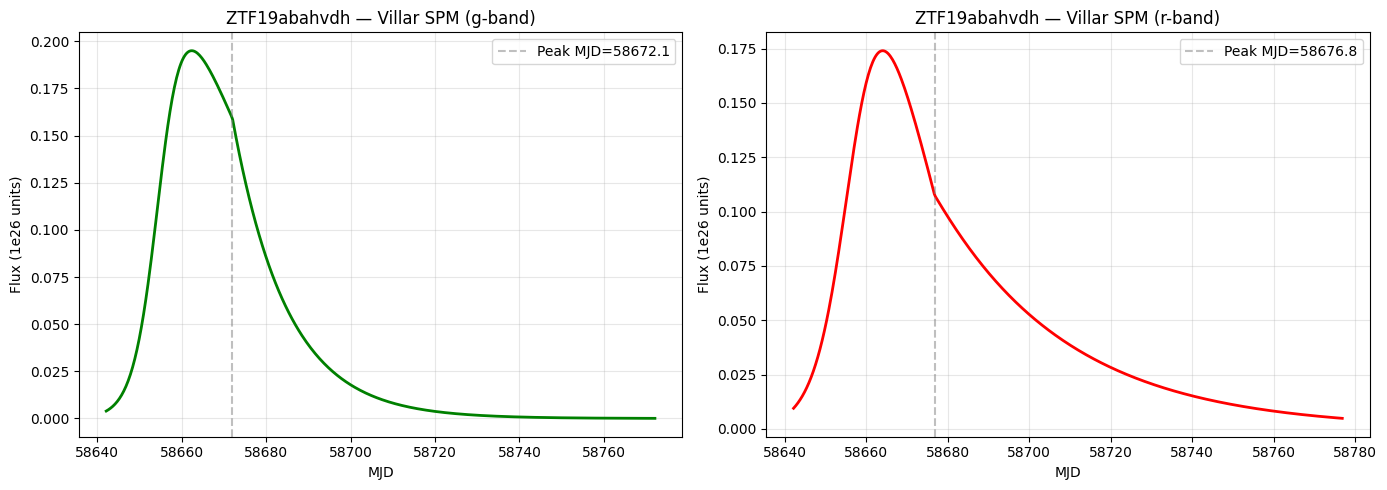

In [34]:
# Plot the Villar model for one object
import matplotlib.pyplot as plt

if db.available and test_oids and len(features) > 0:
    # Pick first object with features
    test_oid = features['oid'].iloc[0]
    row = features[features['oid'] == test_oid].iloc[0]
    firstmjd = firstmjd_lookup.get(test_oid, 59000)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for fid, band, color, ax in [(1, 'g', 'green', axes[0]), (2, 'r', 'red', axes[1])]:
        sfx = f'_{fid}'
        A = row.get(f'SPM_A{sfx}', np.nan)
        t0 = row.get(f'SPM_t0{sfx}', np.nan)
        beta = row.get(f'SPM_beta{sfx}', np.nan)
        gamma = row.get(f'SPM_gamma{sfx}', np.nan)
        tau_rise = row.get(f'SPM_tau_rise{sfx}', np.nan)
        tau_fall = row.get(f'SPM_tau_fall{sfx}', np.nan)
        
        if np.isnan(A):
            ax.text(0.5, 0.5, f'No SPM data for {band}-band', 
                    transform=ax.transAxes, ha='center')
            continue
            
        mjd_grid = np.linspace(firstmjd - 10, firstmjd + t0 + gamma + 100, 500)
        flux = villar_flux(mjd_grid, firstmjd, A, t0, beta, gamma, tau_rise, tau_fall)
        
        ax.plot(mjd_grid, flux, '-', color=color, linewidth=2)
        peak_mjd = firstmjd + t0 + gamma
        ax.axvline(peak_mjd, color='gray', linestyle='--', alpha=0.5, label=f'Peak MJD={peak_mjd:.1f}')
        ax.set_xlabel('MJD')
        ax.set_ylabel('Flux (1e26 units)')
        ax.set_title(f'{test_oid} — Villar SPM ({band}-band)')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 4. NED Redshift Lookups

Query NED for spectroscopic host galaxy redshifts near our test objects.

In [35]:
from utils.ned_query import query_ned_redshift, query_ned_batch

# Test single coordinate — well-known galaxy cluster in COSMOS field
result = query_ned_redshift(150.11, 2.23, radius_arcsec=60)
if result:
    print(f'NED result near COSMOS center:')
    print(f'  Name: {result["ned_name"]}')
    print(f'  Redshift: {result["redshift"]:.4f}')
    print(f'  Distance modulus: {result["distmod"]:.2f} mag')
    print(f'  Separation: {result["separation_arcsec"]:.1f} arcsec')
else:
    print('No NED source with redshift found near COSMOS center')

NED result near COSMOS center:
  Name: COSMOS2015 0611653
  Redshift: 5.8680
  Distance modulus: 48.81 mag
  Separation: 0.0 arcsec


In [36]:
# Batch NED lookup for test objects
if db.available and test_oids:
    test_coords = snia_top[snia_top['oid'].isin(test_oids)][['oid', 'meanra', 'meandec']].copy()
    test_coords = test_coords.rename(columns={'meanra': 'ra', 'meandec': 'dec'})
    
    print(f'Querying NED for {len(test_coords)} objects...')
    ned_results = query_ned_batch(test_coords)
    
    print('\nNED results:')
    display(ned_results[['oid', 'ra', 'dec', 'ned_redshift', 'ned_distmod', 'ned_name', 'ned_sep_arcsec']])

Querying NED for 5 objects...


2026-02-28 22:10:46,858 - utils.ned_query - INFO - NED lookup complete: 5 total (0 cached, 4 queried, 1 no result)



NED results:


,oid,ra,dec,ned_redshift,ned_distmod,ned_name,ned_sep_arcsec
25533,ZTF19aclljyq,26.189246,7.164697,NaN,NaN,,NaN
3607,ZTF19abahvdh,232.864384,7.095238,0.077400,37.716607,SN 2019hxb,0.003
39016,ZTF20aaljgcp,213.993535,68.297612,0.080232,37.799019,SN 2020buv,0.001
38342,ZTF20aakbtyz,175.579198,44.962024,0.091664,38.105774,SN 2020bjg,0.001
36796,ZTF20aahptds,195.221141,62.795956,0.076491,37.689545,SN 2020awr,0.003


## 5. Extinction + NED Combined

For objects with both extinction and redshift, compute absolute magnitudes.

In [37]:
if db.available and test_oids:
    # Combine extinction and NED data
    combined = test_coords.copy()
    
    # Add extinction
    print('Querying extinction...')
    combined = get_extinction_batch(combined)
    
    # Add NED redshifts (already in ned_results)
    combined['ned_redshift'] = ned_results['ned_redshift'].values
    combined['ned_distmod'] = ned_results['ned_distmod'].values
    
    print('\nCombined data:')
    display(combined[['oid', 'ra', 'dec', 'A_g', 'A_r', 'ned_redshift', 'ned_distmod']])
    
    # Example: if we had a peak mag of 20.0 in r-band
    example_mag = 20.0
    for _, row in combined.iterrows():
        if pd.notna(row['A_r']) and pd.notna(row['ned_distmod']):
            m_corrected = example_mag - row['A_r']
            M_abs = m_corrected - row['ned_distmod']
            print(f"\n{row['oid']}: m_r={example_mag} -> m_corrected={m_corrected:.3f} "
                  f"-> M_abs={M_abs:.2f} (z={row['ned_redshift']:.4f})")
            if -20.5 < M_abs < -18.0:
                print('  ^ Consistent with SN Ia absolute magnitude range!')

Querying extinction...


2026-02-28 22:10:47,720 - utils.extinction - INFO - Extinction lookup complete: 5 total (0 cached, 5 queried, 0 failed)



Combined data:


,oid,ra,dec,A_g,A_r,ned_redshift,ned_distmod
25533,ZTF19aclljyq,26.189246,7.164697,0.123,0.089,NaN,NaN
3607,ZTF19abahvdh,232.864384,7.095238,0.152,0.110,0.077400,37.716607
39016,ZTF20aaljgcp,213.993535,68.297612,0.074,0.053,0.080232,37.799019
38342,ZTF20aakbtyz,175.579198,44.962024,0.085,0.061,0.091664,38.105774
36796,ZTF20aahptds,195.221141,62.795956,0.053,0.039,0.076491,37.689545



ZTF19abahvdh: m_r=20.0 -> m_corrected=19.890 -> M_abs=-17.83 (z=0.0774)

ZTF20aaljgcp: m_r=20.0 -> m_corrected=19.947 -> M_abs=-17.85 (z=0.0802)

ZTF20aakbtyz: m_r=20.0 -> m_corrected=19.939 -> M_abs=-18.17 (z=0.0917)
  ^ Consistent with SN Ia absolute magnitude range!

ZTF20aahptds: m_r=20.0 -> m_corrected=19.961 -> M_abs=-17.73 (z=0.0765)


## 6. End-to-End Pipeline Test

Run the full pipeline on one DDF field with all new features enabled.

In [38]:
from supernova_monitor import SupernovaMonitor
from core.ddf_fields import DDF_FIELDS

# Use just COSMOS for a quick test
cosmos = [f for f in DDF_FIELDS if f['name'] == 'COSMOS']

monitor = SupernovaMonitor(
    cache_dir='./cache/data',
    use_alerce_db=True,
    apply_extinction=True,
    query_ned=True,
)

print('Pipeline initialized with all new features')
print(f'Brokers available: {list(monitor.brokers.keys())}')

2026-02-28 22:10:47,811 - cache.alert_cache - INFO - Initialized cache database at ./cache/data/alerts_cache.db


2026-02-28 22:10:47,812 - cache.alert_cache - INFO - Initialized cache database at ./cache/data/alerts_cache.db


2026-02-28 22:10:47,813 - cache.alert_cache - INFO - Initialized cache database at ./cache/data/alerts_cache.db


2026-02-28 22:10:47,818 - core.variable_screen - INFO - Loaded 1937 variables from COSMOS_variables.csv


2026-02-28 22:10:47,822 - core.variable_screen - INFO - Loaded 1587 variables from XMM-LSS_variables.csv


...

2026-02-28 22:10:47,863 - broker_clients.alerce_client - INFO - ALeRCE client initialized successfully (survey=ztf)


2026-02-28 22:10:47,863 - supernova_monitor - INFO - ALeRCE (ZTF) client initialized (db=True)


2026-02-28 22:10:47,865 - broker_clients.alerce_client - INFO - ALeRCE client initialized successfully (survey=lsst)


2026-02-28 22:10:47,865 - supernova_monitor - INFO - ALeRCE (LSST) client initialized


Pipeline initialized with all new features
Brokers available: ['ANTARES', 'ALeRCE', 'ALeRCE-LSST']


In [39]:
# Run pipeline on COSMOS only, with relaxed thresholds for testing
results = monitor.run_full_pipeline(
    min_ia_probability=0.3,
    days_back=90,
    limit=50,
    ddf_fields=cosmos,
    require_rubin=False,
    atlas_enrichment=False,  # skip ATLAS to keep test fast
)

if results is not None and len(results) > 0:
    print(f'\nPipeline returned {len(results)} candidates')
    
    # Check which new columns are present
    new_cols = [c for c in results.columns if c.startswith(('A_', 'ned_'))]
    print(f'New columns: {new_cols}')
    
    # Show a few rows with new data
    show_cols = ['unique_id', 'ra', 'dec', 'mean_ia_prob', 'num_brokers']
    show_cols += [c for c in new_cols if c in results.columns]
    display(results[show_cols].head(10))
else:
    print('No candidates returned (check broker connectivity)')

2026-02-28 22:10:48,254 - supernova_monitor - INFO - ============================================================


2026-02-28 22:10:48,254 - supernova_monitor - INFO - Starting SuperNova Monitoring Pipeline


2026-02-28 22:10:48,255 - supernova_monitor - INFO - Time: 2026-02-28T22:10:48.255472


2026-02-28 22:10:48,255 - supernova_monitor - INFO - DDFs: COSMOS


2026-02-28 22:10:48,256 - supernova_monitor - INFO - Parameters: P(Ia) >= 0.3, days_back=90, limit=50, require_rubin=False, elliptical_filter=False, atlas_enrichment=False


...

2026-02-28 22:12:03,063 - supernova_monitor - INFO - ============================================================


2026-02-28 22:12:03,063 - supernova_monitor - INFO - FINAL: 76 Type Ia candidates


2026-02-28 22:12:03,064 - supernova_monitor - INFO - ============================================================



Pipeline returned 76 candidates
New columns: ['A_u', 'A_g', 'A_r', 'A_i', 'A_z', 'ned_redshift', 'ned_distmod', 'ned_name', 'ned_sep_arcsec']


,unique_id,ra,dec,mean_ia_prob,num_brokers,A_u,A_g,A_r,A_i,A_z,ned_redshift,ned_distmod,ned_name,ned_sep_arcsec
0,149.49365_2.37231,149.493653,2.372306,0.45,1,0.106,0.078,0.057,0.043,0.031,0.495700,42.247444,zCOSMOS 834854,0.111
1,150.16602_2.10977,150.166016,2.109765,0.45,1,0.088,0.065,0.047,0.036,0.025,2.068800,46.089059,COSMOS2015 0531486,0.021
2,149.86064_3.42369,149.860635,3.423690,0.45,1,0.115,0.085,0.061,0.047,0.033,1.061780,44.287134,DESI J149.8577+03.4257,0.213
3,150.99906_2.48992,150.999059,2.489920,0.45,1,0.119,0.088,0.064,0.048,0.034,NaN,NaN,,NaN
4,151.47973_2.40489,151.479734,2.404890,0.35,1,0.222,0.163,0.118,0.090,0.064,NaN,NaN,,NaN
5,150.21591_1.77394,150.215912,1.773942,0.45,1,0.095,0.070,0.051,0.039,0.027,2.166600,46.212567,COSMOS 0522834,0.056
6,150.10708_3.85357,150.107076,3.853568,0.45,1,0.125,0.092,0.066,0.050,0.036,0.057778,37.050902,SDSS J100026.44+035104.2,0.232
7,149.84615_3.85717,149.846154,3.857174,0.45,1,0.132,0.097,0.070,0.053,0.038,NaN,NaN,,NaN
8,151.71209_1.97280,151.712095,1.972802,0.45,1,0.172,0.127,0.092,0.070,0.049,NaN,NaN,,NaN
9,148.50320_2.83809,148.503199,2.838095,0.45,1,0.254,0.187,0.136,0.103,0.073,NaN,NaN,,NaN


In [40]:
# Summary statistics
if results is not None and len(results) > 0:
    print('=== New Feature Coverage ===')
    
    if 'A_g' in results.columns:
        n_ext = results['A_g'].notna().sum()
        print(f'Extinction:  {n_ext}/{len(results)} have A_g values')
        if n_ext > 0:
            print(f'  A_g range: {results["A_g"].min():.4f} - {results["A_g"].max():.4f}')
    
    if 'ned_redshift' in results.columns:
        n_z = results['ned_redshift'].notna().sum()
        print(f'NED redshift: {n_z}/{len(results)} have spectroscopic z')
        if n_z > 0:
            print(f'  z range: {results["ned_redshift"].min():.4f} - {results["ned_redshift"].max():.4f}')
    
    print(f'\nBroker breakdown:')
    print(results['brokers_detected'].value_counts().to_string())

=== New Feature Coverage ===
Extinction:  76/76 have A_g values
  A_g range: 0.0650 - 0.2560
NED redshift: 52/76 have spectroscopic z
  z range: -0.0001 - 2.1666

Broker breakdown:
brokers_detected
ANTARES        50
ALeRCE-LSST    25
ALeRCE          1


## 7. Cache Verification

Check that extinction and NED data were cached in SQLite.

In [41]:
from cache.alert_cache import AlertCache

cache = AlertCache('./cache/data')

# Test extinction cache retrieval (should be instant, no IRSA query)
cached_ext = cache.get_cached_extinction(150.11, 2.23)
if cached_ext:
    print('Cached extinction for COSMOS center:', cached_ext)
else:
    print('No cached extinction (run extinction test first)')

# Test NED cache
cached_ned = cache.get_cached_ned_info(150.11, 2.23)
if cached_ned:
    print('Cached NED info for COSMOS center:', cached_ned)
else:
    print('No cached NED info')

2026-02-28 22:12:03,076 - cache.alert_cache - INFO - Initialized cache database at ./cache/data/alerts_cache.db


No cached extinction (run extinction test first)
No cached NED info


## 8. Light Curves with Villar Fits and Peak Markers

Fetch ZTF light curves from the ALeRCE database, overlay Villar SPM model fits,
and mark the predicted peak epoch with vertical lines.

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from core.peak_fitting import villar_flux, extract_villar_peaks
from broker_clients.alerce_db_client import AlerceDBClient

# Reconnect if needed
if not db.available:
    raise RuntimeError('psycopg2 required for this section')
db._ensure_connected()

# Get a sample of well-classified SNIa candidates
candidates = db.query_sn_candidates(min_prob=0.3)
snia = candidates[(candidates['class_name'] == 'SNIa') & (candidates['ranking'] == 1)]
snia = snia.sort_values('probability', ascending=False)

# Take top 12 for a nice grid
n_plot = 12
sample_oids = snia['oid'].head(n_plot).tolist()
print(f'Selected {len(sample_oids)} SNIa candidates for light curve plots')

# Fetch light curves, SPM features
detections = db.query_detections(sample_oids)
features = db.query_features(sample_oids, prefix='SPM')
firstmjd_lookup = dict(zip(snia['oid'], snia['firstmjd']))

# Extract Villar peaks
villar_peaks = extract_villar_peaks(features, firstmjd_lookup)

print(f'Detections: {len(detections)} photometric points')
print(f'SPM features for {len(features)} objects')
print(f'Villar peaks for {len(villar_peaks)} objects')

2026-02-28 22:12:04,600 - broker_clients.alerce_db_client - INFO - ALeRCE DB: queried 50000 rows for SN candidates (prob > 0.30)


2026-02-28 22:12:04,752 - broker_clients.alerce_db_client - INFO - ALeRCE DB: 371 detections for 12 objects


Selected 12 SNIa candidates for light curve plots


2026-02-28 22:12:04,889 - broker_clients.alerce_db_client - INFO - ALeRCE DB: SPM features for 12 objects (14 columns)


Detections: 371 photometric points
SPM features for 12 objects
Villar peaks for 12 objects


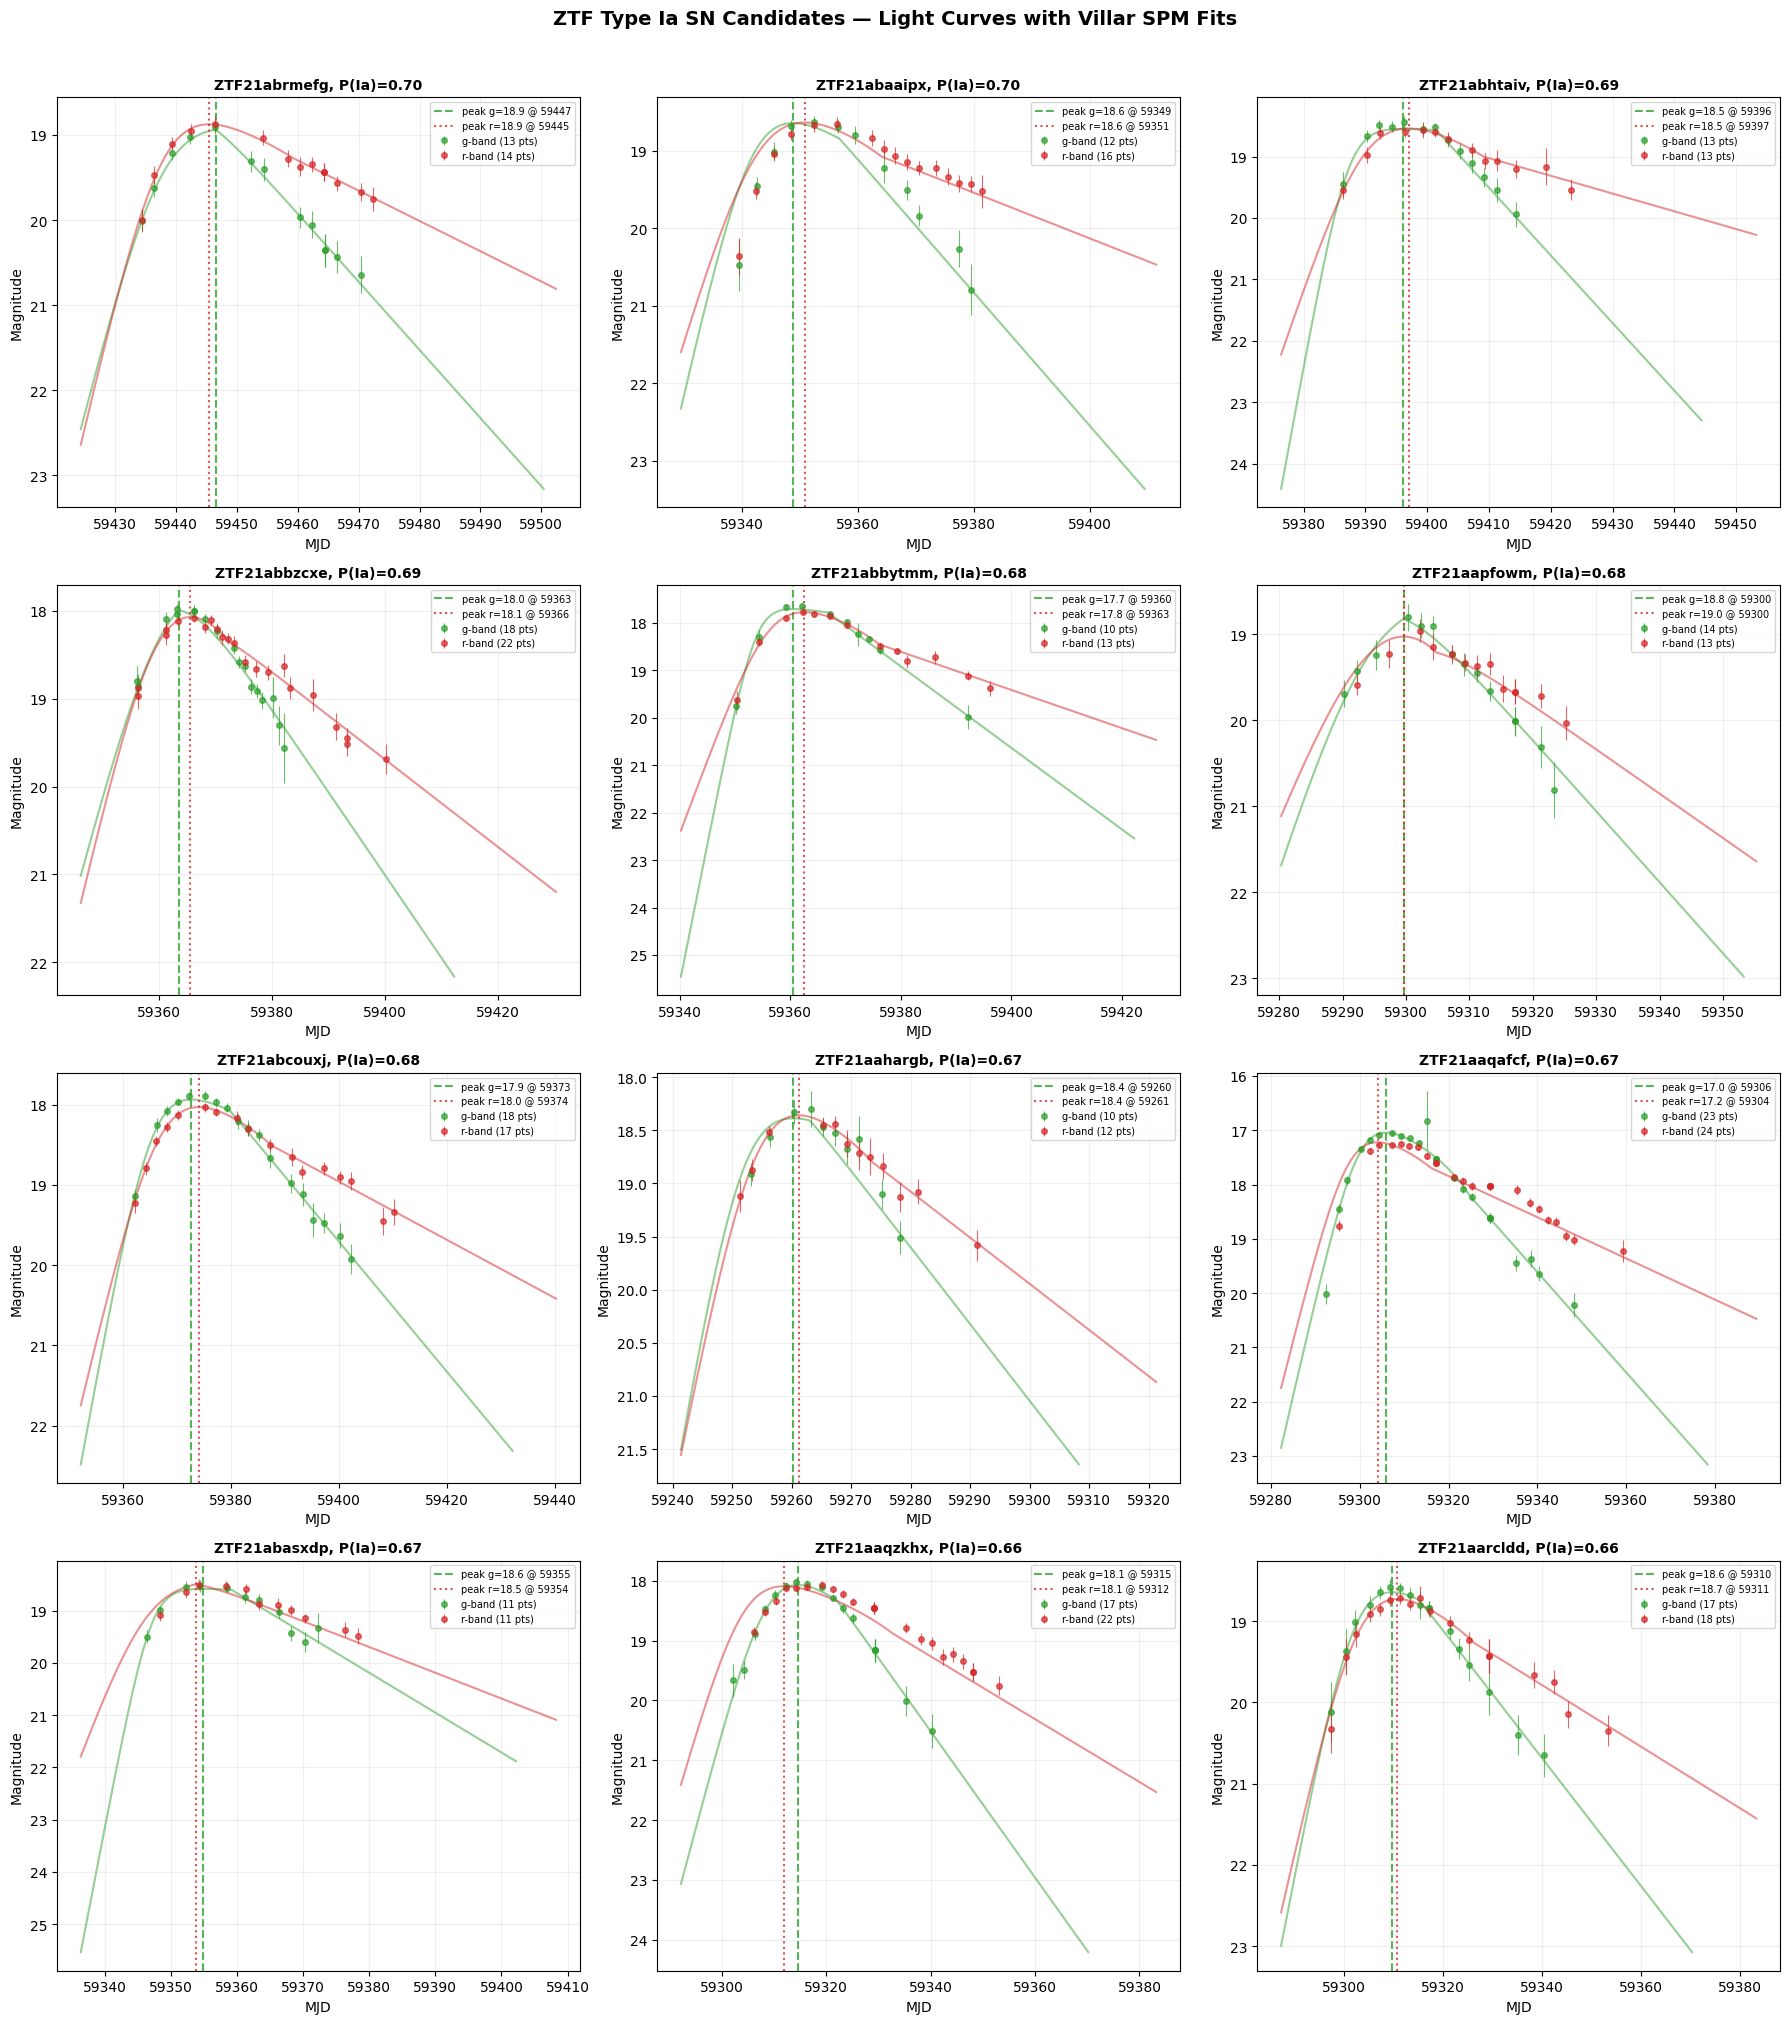

In [43]:
# Plot light curves with Villar model fits and peak markers
band_config = {
    1: {'label': 'g', 'color': '#2ca02c', 'peak_ls': '--'},  # green
    2: {'label': 'r', 'color': '#d62728', 'peak_ls': ':'},    # red
}

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for idx, oid in enumerate(sample_oids):
    ax = axes[idx]
    
    # Get this object's detections
    obj_det = detections[detections['oid'] == oid]
    firstmjd = firstmjd_lookup.get(oid, np.nan)
    
    # Get SPM features for this object
    obj_feat = features[features['oid'] == oid]
    has_spm = len(obj_feat) > 0
    if has_spm:
        feat_row = obj_feat.iloc[0]
    
    # Plot each band
    for fid, cfg in band_config.items():
        band_det = obj_det[obj_det['fid'] == fid]
        if len(band_det) == 0:
            continue
        
        # Photometry with error bars
        ax.errorbar(
            band_det['mjd'], band_det['magpsf'],
            yerr=band_det['sigmapsf'],
            fmt='o', ms=4, color=cfg['color'], alpha=0.7,
            label=f'{cfg["label"]}-band ({len(band_det)} pts)',
            capsize=0, elinewidth=0.8,
        )
        
        # Villar SPM model overlay
        if has_spm and not np.isnan(firstmjd):
            sfx = f'_{fid}'
            A = feat_row.get(f'SPM_A{sfx}', np.nan)
            t0 = feat_row.get(f'SPM_t0{sfx}', np.nan)
            beta = feat_row.get(f'SPM_beta{sfx}', np.nan)
            gamma = feat_row.get(f'SPM_gamma{sfx}', np.nan)
            tau_rise = feat_row.get(f'SPM_tau_rise{sfx}', np.nan)
            tau_fall = feat_row.get(f'SPM_tau_fall{sfx}', np.nan)
            
            if not np.isnan(A):
                # Generate model curve over the data range
                mjd_min = max(band_det['mjd'].min() - 15, firstmjd - 10)
                mjd_max = band_det['mjd'].max() + 30
                mjd_grid = np.linspace(mjd_min, mjd_max, 300)
                flux_model = villar_flux(
                    mjd_grid, firstmjd, A, t0, beta, gamma, tau_rise, tau_fall
                )
                # Convert flux to mag: mag = -2.5*log10(flux) + 2.5*26 - 48.6
                with np.errstate(divide='ignore', invalid='ignore'):
                    mag_model = np.where(
                        flux_model > 0,
                        -2.5 * np.log10(flux_model) + 16.4,
                        np.nan,
                    )
                ax.plot(mjd_grid, mag_model, '-', color=cfg['color'],
                        alpha=0.5, linewidth=1.5)
        
        # Peak vertical line
        peaks = villar_peaks.get(oid, {})
        band_peak = peaks.get(cfg['label'])
        if band_peak and band_peak['status'] == 'ok':
            peak_mjd = band_peak['peak_mjd']
            peak_mag = band_peak['peak_mag']
            ax.axvline(peak_mjd, color=cfg['color'], linestyle=cfg['peak_ls'],
                       alpha=0.8, linewidth=1.5,
                       label=f'peak {cfg["label"]}={peak_mag:.1f} @ {peak_mjd:.0f}')
    
    # Formatting
    ax.invert_yaxis()
    ax.set_xlabel('MJD')
    ax.set_ylabel('Magnitude')
    
    # Get P(Ia) for title
    prob = snia[snia['oid'] == oid]['probability'].values
    prob_str = f', P(Ia)={prob[0]:.2f}' if len(prob) > 0 else ''
    ax.set_title(f'{oid}{prob_str}', fontsize=10, fontweight='bold')
    
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.2)

plt.suptitle('ZTF Type Ia SN Candidates — Light Curves with Villar SPM Fits',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Peak Magnitude vs Peak MJD for Type Ia Candidates

Extract Villar peak estimates for a larger sample and plot the predicted
peak apparent magnitude against peak epoch. This is the key diagnostic for
scheduling spectroscopic follow-up: objects near peak and bright enough
for Magellan are highest priority.

In [44]:
# Extract Villar peaks for a larger SNIa sample
n_sample = 200
sample_oids_lg = snia['oid'].head(n_sample).tolist()
print(f'Fetching SPM features for {len(sample_oids_lg)} SNIa candidates...')

features_lg = db.query_features(sample_oids_lg, prefix='SPM')
firstmjd_lookup_lg = dict(zip(snia['oid'], snia['firstmjd']))
villar_peaks_lg = extract_villar_peaks(features_lg, firstmjd_lookup_lg)

# Build a table of peak estimates
peak_rows = []
for oid, bands in villar_peaks_lg.items():
    prob_val = snia[snia['oid'] == oid]['probability'].values
    p_ia = prob_val[0] if len(prob_val) > 0 else np.nan
    for band, result in bands.items():
        if result['status'] == 'ok':
            peak_rows.append({
                'oid': oid,
                'band': band,
                'peak_mjd': result['peak_mjd'],
                'peak_mag': result['peak_mag'],
                'p_ia': p_ia,
            })

peaks_df = pd.DataFrame(peak_rows)
print(f'Valid peak estimates: {len(peaks_df)} ({peaks_df["oid"].nunique()} objects, '
      f'{len(peaks_df[peaks_df["band"]=="g"])} g-band, '
      f'{len(peaks_df[peaks_df["band"]=="r"])} r-band)')
display(peaks_df.describe())

Fetching SPM features for 200 SNIa candidates...


2026-02-28 22:12:05,789 - broker_clients.alerce_db_client - INFO - ALeRCE DB: SPM features for 200 objects (14 columns)


Valid peak estimates: 400 (200 objects, 200 g-band, 200 r-band)


,peak_mjd,peak_mag,p_ia
count,400.000000,400.000000,400.000000
mean,59342.270560,18.460774,0.596161
std,155.021551,0.611357,0.037208
min,59231.366265,16.512907,0.538560
25%,59297.162751,18.083678,0.564000
50%,59325.182520,18.546573,0.593184
75%,59360.612103,18.923935,0.620000
max,60937.438909,19.863477,0.696000


/var/folders/vn/_16wlq8x7y7b4xzlz_s73j8h0000gn/T/ipykernel_38481/1881129270.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


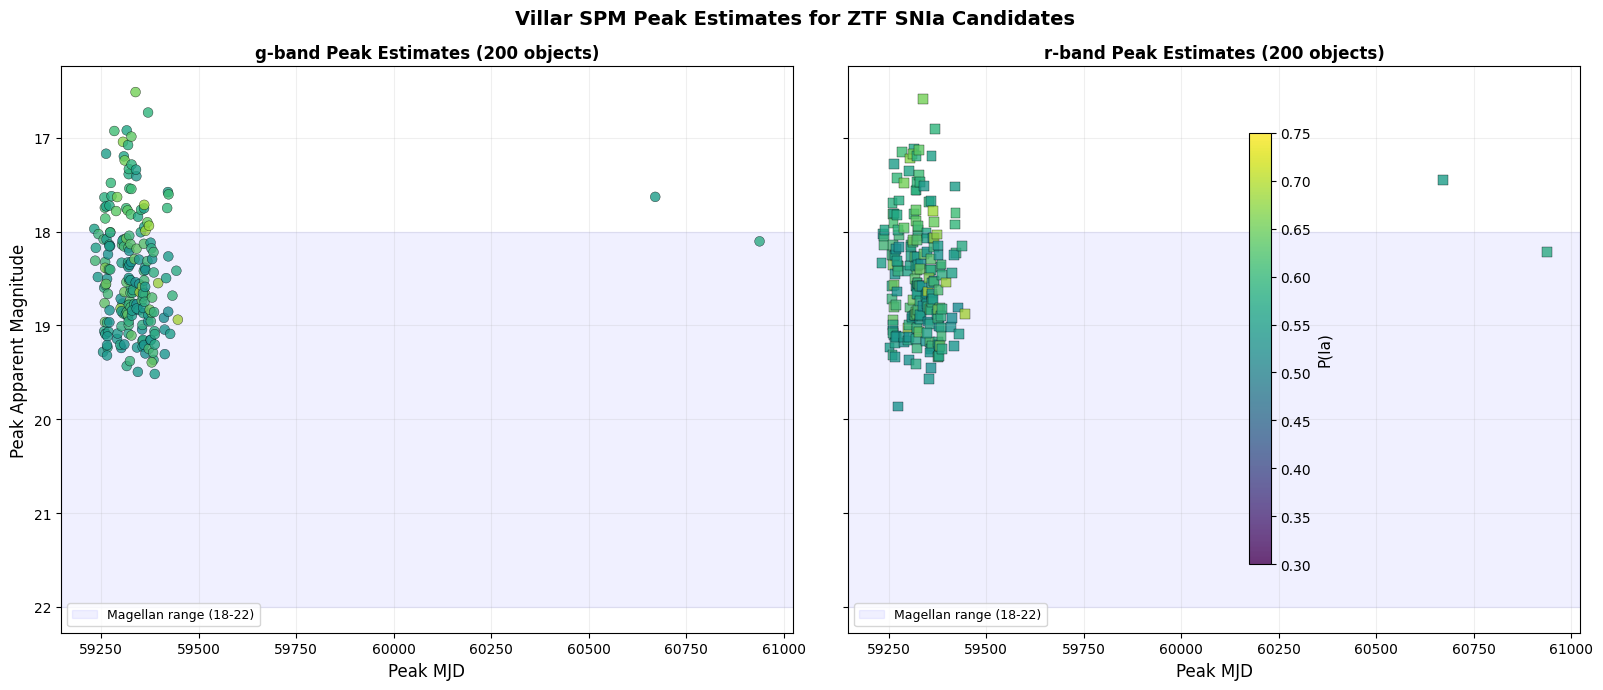


Median peak mag: g=18.6, r=18.5
MJD range: 59231 - 60937


In [45]:
# 2D scatter: Peak MJD vs Peak Magnitude for SNIa candidates
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, band, color, marker in [
    (axes[0], 'g', '#2ca02c', 'o'),
    (axes[1], 'r', '#d62728', 's'),
]:
    bdf = peaks_df[peaks_df['band'] == band]
    
    sc = ax.scatter(
        bdf['peak_mjd'], bdf['peak_mag'],
        c=bdf['p_ia'], cmap='viridis', vmin=0.3, vmax=0.75,
        s=50, marker=marker, edgecolors='k', linewidth=0.3, alpha=0.8,
    )
    
    # Mark the "sweet spot" for Magellan follow-up
    ax.axhspan(18.0, 22.0, alpha=0.06, color='blue',
               label='Magellan range (18-22)')
    
    ax.set_xlabel('Peak MJD', fontsize=12)
    ax.set_title(f'{band}-band Peak Estimates ({len(bdf)} objects)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='lower left')
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Peak Apparent Magnitude', fontsize=12)
axes[0].invert_yaxis()

# Shared colorbar
cbar = fig.colorbar(sc, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label('P(Ia)', fontsize=11)

plt.suptitle('Villar SPM Peak Estimates for ZTF SNIa Candidates',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nMedian peak mag: g={peaks_df[peaks_df["band"]=="g"]["peak_mag"].median():.1f}, '
      f'r={peaks_df[peaks_df["band"]=="r"]["peak_mag"].median():.1f}')
print(f'MJD range: {peaks_df["peak_mjd"].min():.0f} - {peaks_df["peak_mjd"].max():.0f}')

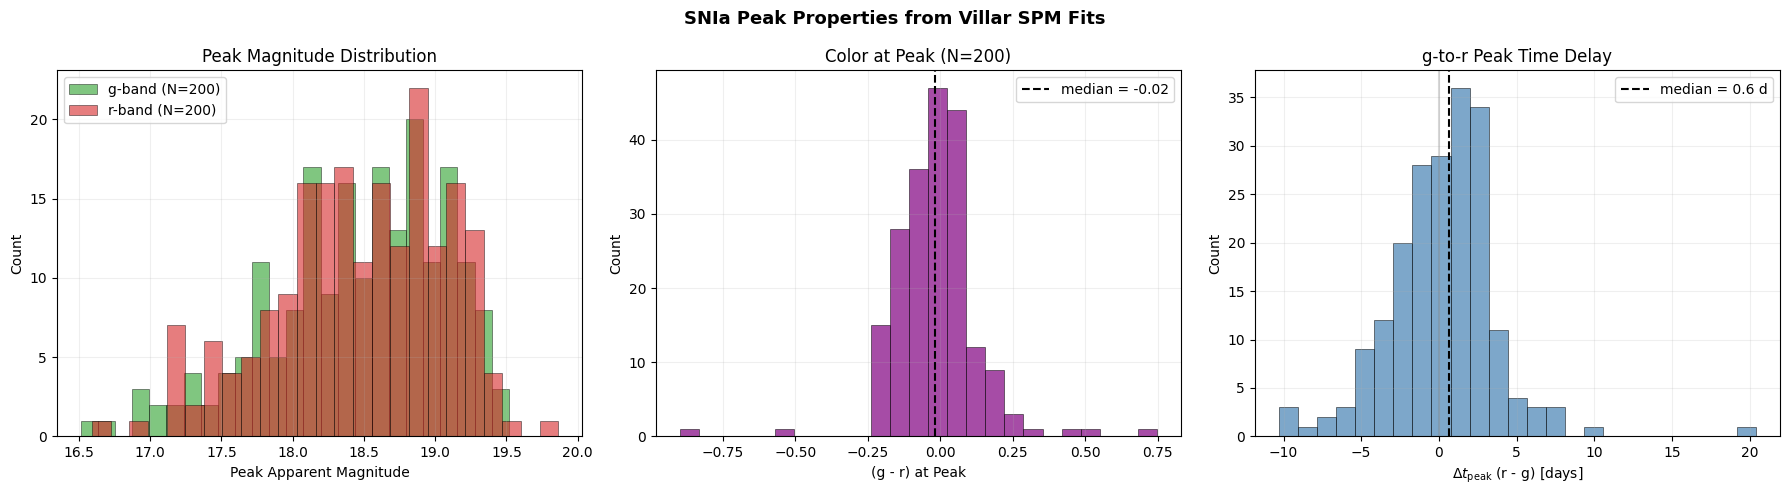

g-r at peak: median=-0.02, std=0.15
Peak time delay (r-g): median=0.6 d, std=3.5 d


In [46]:
# Peak magnitude distributions and g-r color at peak
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Peak mag histograms by band
ax = axes[0]
for band, color, label in [('g', '#2ca02c', 'g-band'), ('r', '#d62728', 'r-band')]:
    mags = peaks_df[peaks_df['band'] == band]['peak_mag']
    ax.hist(mags, bins=25, alpha=0.6, color=color, label=f'{label} (N={len(mags)})',
            edgecolor='k', linewidth=0.5)
ax.set_xlabel('Peak Apparent Magnitude')
ax.set_ylabel('Count')
ax.set_title('Peak Magnitude Distribution')
ax.legend()
ax.grid(True, alpha=0.2)

# Panel 2: g-r color at peak
ax = axes[1]
# Merge g and r peaks per object
g_peaks = peaks_df[peaks_df['band'] == 'g'][['oid', 'peak_mag', 'peak_mjd']].rename(
    columns={'peak_mag': 'peak_g', 'peak_mjd': 'peak_mjd_g'})
r_peaks = peaks_df[peaks_df['band'] == 'r'][['oid', 'peak_mag', 'peak_mjd']].rename(
    columns={'peak_mag': 'peak_r', 'peak_mjd': 'peak_mjd_r'})
gr_df = g_peaks.merge(r_peaks, on='oid', how='inner')
gr_df['g_minus_r'] = gr_df['peak_g'] - gr_df['peak_r']
gr_df['dt_peak'] = gr_df['peak_mjd_r'] - gr_df['peak_mjd_g']  # r peaks later for Ia

ax.hist(gr_df['g_minus_r'], bins=25, alpha=0.7, color='purple',
        edgecolor='k', linewidth=0.5)
ax.axvline(gr_df['g_minus_r'].median(), color='k', linestyle='--',
           label=f'median = {gr_df["g_minus_r"].median():.2f}')
ax.set_xlabel('(g - r) at Peak')
ax.set_ylabel('Count')
ax.set_title(f'Color at Peak (N={len(gr_df)})')
ax.legend()
ax.grid(True, alpha=0.2)

# Panel 3: Time delay between g and r peaks
ax = axes[2]
ax.hist(gr_df['dt_peak'], bins=25, alpha=0.7, color='steelblue',
        edgecolor='k', linewidth=0.5)
ax.axvline(gr_df['dt_peak'].median(), color='k', linestyle='--',
           label=f'median = {gr_df["dt_peak"].median():.1f} d')
ax.axvline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('$\\Delta t_{\\mathrm{peak}}$ (r - g) [days]')
ax.set_ylabel('Count')
ax.set_title('g-to-r Peak Time Delay')
ax.legend()
ax.grid(True, alpha=0.2)

plt.suptitle('SNIa Peak Properties from Villar SPM Fits',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'g-r at peak: median={gr_df["g_minus_r"].median():.2f}, '
      f'std={gr_df["g_minus_r"].std():.2f}')
print(f'Peak time delay (r-g): median={gr_df["dt_peak"].median():.1f} d, '
      f'std={gr_df["dt_peak"].std():.1f} d')

## 10. Redshift Distribution

NED spectroscopic redshifts for the SNIa candidate sample. These come from
host galaxy matches within 18 arcsec of each transient position.

In [47]:
# Query NED redshifts for the larger SNIa sample
from utils.ned_query import query_ned_batch

# Build coordinates table for the 200 SNIa sample
snia_coords = snia[snia['oid'].isin(sample_oids_lg)][['oid', 'meanra', 'meandec']].copy()
snia_coords = snia_coords.rename(columns={'meanra': 'ra', 'meandec': 'dec'})

print(f'Querying NED for {len(snia_coords)} SNIa candidates...')
ned_snia = query_ned_batch(snia_coords)

n_z = ned_snia['ned_redshift'].notna().sum()
print(f'NED redshift matches: {n_z}/{len(ned_snia)} ({100*n_z/len(ned_snia):.0f}%)')

# Filter to valid, positive redshifts
z_valid = ned_snia['ned_redshift'].dropna()
z_valid = z_valid[z_valid > 0]
print(f'Valid positive redshifts: {len(z_valid)}')
print(f'  Range: {z_valid.min():.4f} - {z_valid.max():.4f}')
print(f'  Median: {z_valid.median():.4f}')

Querying NED for 200 SNIa candidates...


2026-02-28 22:12:19,426 - utils.ned_query - INFO - NED lookup: 25/200 done (0 cached, 13 queried, 12 no result)


2026-02-28 22:12:33,145 - utils.ned_query - INFO - NED lookup: 50/200 done (0 cached, 27 queried, 23 no result)


2026-02-28 22:12:47,155 - utils.ned_query - INFO - NED lookup: 75/200 done (0 cached, 41 queried, 34 no result)


2026-02-28 22:13:01,197 - utils.ned_query - INFO - NED lookup: 100/200 done (0 cached, 54 queried, 46 no result)


...

2026-02-28 22:13:30,599 - utils.ned_query - INFO - NED lookup: 150/200 done (0 cached, 82 queried, 68 no result)


2026-02-28 22:13:45,136 - utils.ned_query - INFO - NED lookup: 175/200 done (0 cached, 94 queried, 81 no result)


2026-02-28 22:13:59,005 - utils.ned_query - INFO - NED lookup: 200/200 done (0 cached, 103 queried, 97 no result)


2026-02-28 22:13:59,006 - utils.ned_query - INFO - NED lookup complete: 200 total (0 cached, 103 queried, 97 no result)


NED redshift matches: 103/200 (52%)
Valid positive redshifts: 103
  Range: 0.0276 - 0.4433
  Median: 0.0697


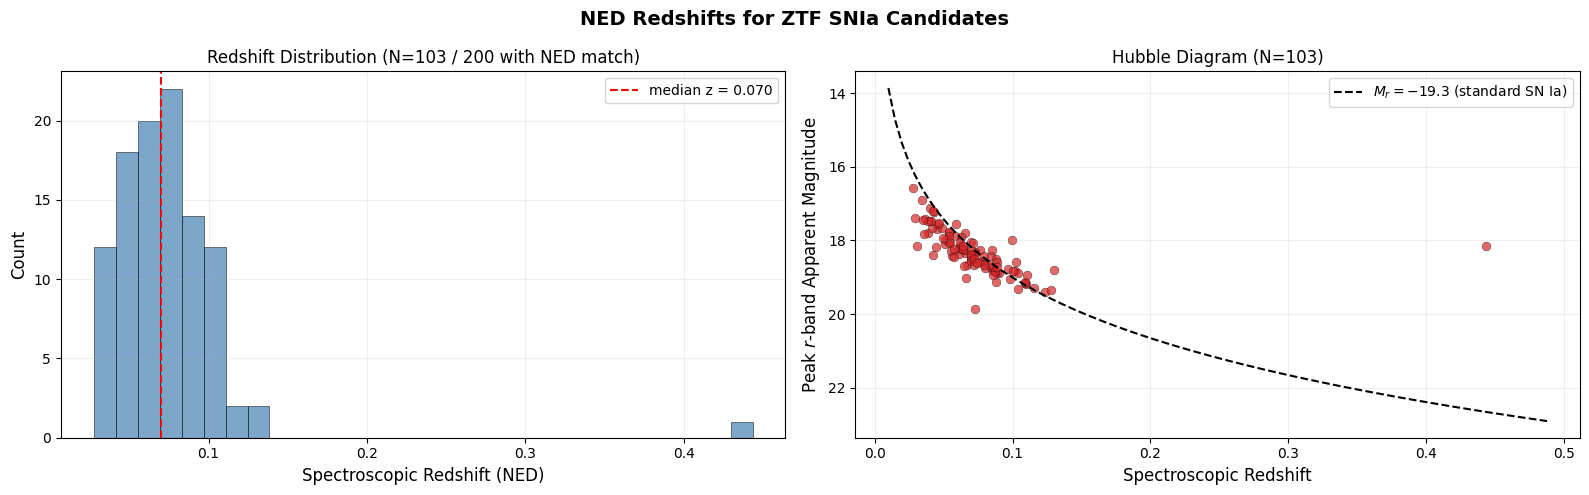

In [48]:
# Redshift histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Full redshift distribution
ax = axes[0]
ax.hist(z_valid, bins=30, alpha=0.7, color='steelblue', edgecolor='k', linewidth=0.5)
ax.axvline(z_valid.median(), color='red', linestyle='--', linewidth=1.5,
           label=f'median z = {z_valid.median():.3f}')
ax.set_xlabel('Spectroscopic Redshift (NED)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Redshift Distribution (N={len(z_valid)} / {len(ned_snia)} with NED match)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

# Panel 2: Redshift vs peak r-band magnitude (Hubble diagram)
ax = axes[1]
# Merge redshifts with r-band peak estimates
r_peaks_z = peaks_df[peaks_df['band'] == 'r'][['oid', 'peak_mag']].copy()
r_peaks_z = r_peaks_z.merge(
    ned_snia[['oid', 'ned_redshift', 'ned_distmod']],
    on='oid', how='inner',
)
r_peaks_z = r_peaks_z[r_peaks_z['ned_redshift'] > 0].copy()

if len(r_peaks_z) > 0:
    ax.scatter(r_peaks_z['ned_redshift'], r_peaks_z['peak_mag'],
               s=40, c='#d62728', edgecolors='k', linewidth=0.3, alpha=0.7)
    
    # Overlay expected apparent mag for M_r = -19.3 (standard SN Ia)
    import numpy as np
    z_grid = np.linspace(0.01, r_peaks_z['ned_redshift'].max() * 1.1, 100)
    from astropy.cosmology import WMAP7
    distmod_grid = WMAP7.distmod(z_grid).value
    m_expected = -19.3 + distmod_grid
    ax.plot(z_grid, m_expected, 'k--', linewidth=1.5,
            label='$M_r = -19.3$ (standard SN Ia)')
    
    ax.set_xlabel('Spectroscopic Redshift', fontsize=12)
    ax.set_ylabel('Peak $r$-band Apparent Magnitude', fontsize=12)
    ax.set_title(f'Hubble Diagram (N={len(r_peaks_z)})')
    ax.legend(fontsize=10)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.2)

plt.suptitle('NED Redshifts for ZTF SNIa Candidates', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Elliptical Host Galaxy Classification

The pipeline classifies host galaxy morphology using color cuts on catalog photometry
(SDSS or Pan-STARRS). The classification thresholds are:
- **Elliptical** (red sequence): g-r > 0.55 **and** r-i > 0.15
- **Spiral** (blue cloud): g-r < 0.45 **and** r-i < 0.15
- **Uncertain**: intermediate colors

**Important caveat:** This analysis uses PS1/SDSS photometry, which is only available
for the northern sky (dec > -30 for PS1, limited SDSS footprint). Most Rubin DDF
fields (ECDFS, ELAIS-S1, EDFS) are in the southern sky where neither catalog has
coverage. For Rubin operations, host morphology classification will need to come from
Rubin's own photometry or southern catalogs (DES, SkyMapper, VHS).

In [49]:
# Get PS1 host galaxy photometry for the full SNIa sample from ALeRCE DB
# This is ZTF-associated PS1 data — only available for dec > -30
ps1_hosts = db.query_ps1_host(sample_oids_lg)
print(f'PS1 host data retrieved for {len(ps1_hosts)} / {len(sample_oids_lg)} SNIa candidates')

# Clean out bad values (-999 = no data in PS1)
ps1_clean = ps1_hosts.copy()
for col in ['sgmag1', 'srmag1', 'simag1', 'szmag1']:
    ps1_clean.loc[ps1_clean[col] < 0, col] = np.nan

# Compute host colors
ps1_clean['g_r'] = ps1_clean['sgmag1'] - ps1_clean['srmag1']
ps1_clean['r_i'] = ps1_clean['srmag1'] - ps1_clean['simag1']

# Apply the same morphology classification as the pipeline
def classify_host(row):
    if pd.isna(row['g_r']) or pd.isna(row['r_i']):
        return 'unknown'
    if row['g_r'] > 0.55 and row['r_i'] > 0.15:
        return 'elliptical'
    elif row['g_r'] < 0.45 and row['r_i'] < 0.15:
        return 'spiral'
    else:
        return 'uncertain'

ps1_clean['morphology'] = ps1_clean.apply(classify_host, axis=1)

# Also classify by star/galaxy score
ps1_clean['sg_class'] = np.where(
    ps1_clean['sgscore1'] < 0.5, 'galaxy',
    np.where(ps1_clean['sgscore1'] >= 0.5, 'star/ambiguous', 'unknown')
)

# Summary
print(f'\nHost morphology classification:')
print(ps1_clean['morphology'].value_counts().to_string())
print(f'\nStar/galaxy score classification:')
print(ps1_clean['sg_class'].value_counts().to_string())

n_valid = ps1_clean['morphology'].isin(['elliptical', 'spiral', 'uncertain']).sum()
n_ell = (ps1_clean['morphology'] == 'elliptical').sum()
print(f'\nElliptical fraction: {n_ell}/{n_valid} = {100*n_ell/n_valid:.1f}% '
      f'(of hosts with valid colors)')

2026-02-28 22:13:59,601 - broker_clients.alerce_db_client - INFO - ALeRCE DB: PS1 host data for 243 objects


PS1 host data retrieved for 243 / 200 SNIa candidates

Host morphology classification:
morphology
uncertain     120
elliptical     60
unknown        44
spiral         19

Star/galaxy score classification:
sg_class
galaxy            195
star/ambiguous     48

Elliptical fraction: 60/199 = 30.2% (of hosts with valid colors)


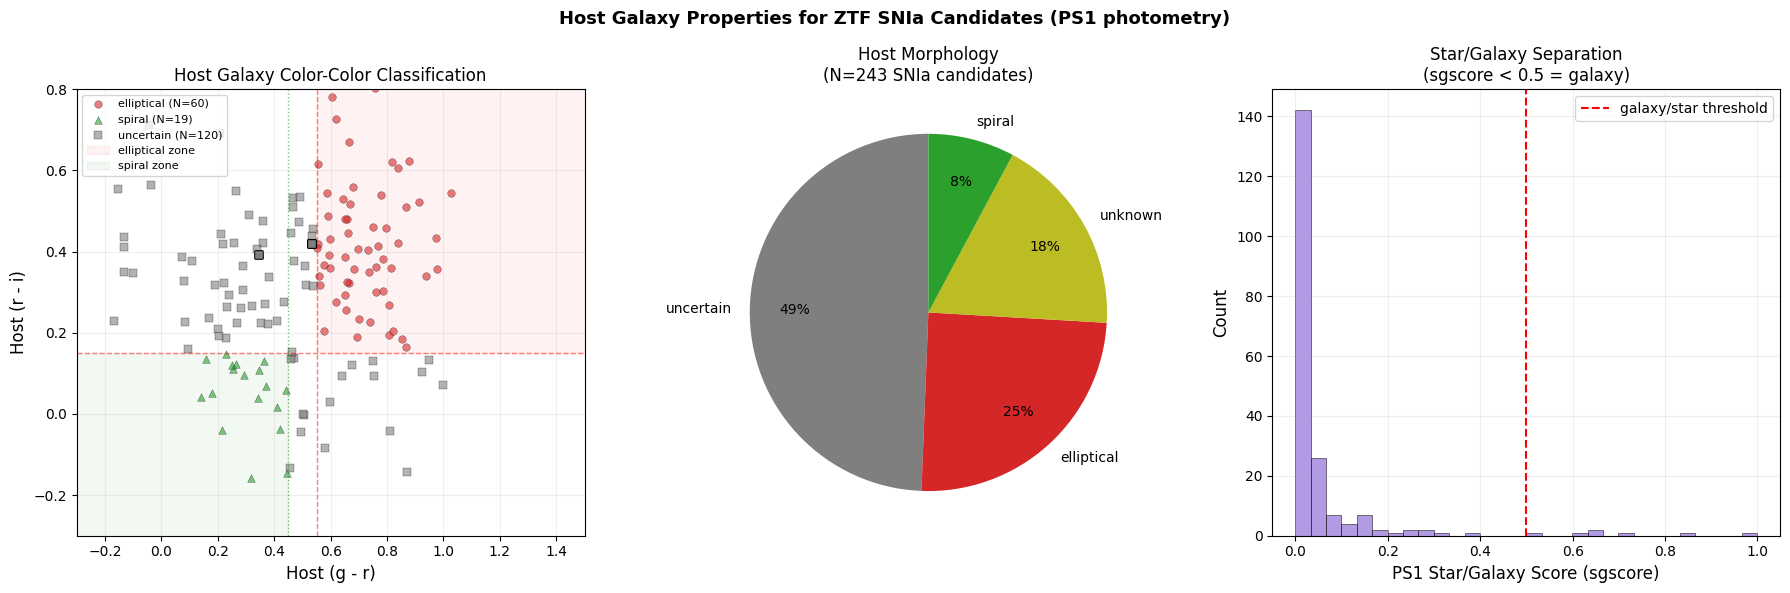


PS1/SDSS coverage by DDF field:
  COSMOS (dec +2):    PS1 yes, SDSS yes
  XMM-LSS (dec -5):   PS1 yes, SDSS partial
  ECDFS (dec -28):    PS1 marginal, SDSS no
  ELAIS-S1 (dec -44): PS1 no, SDSS no
  EDFS (dec -49):     PS1 no, SDSS no
  M49 (dec +8):       PS1 yes, SDSS yes

=> Host morphology from PS1/SDSS colors only works for ~3 of 7 DDFs.
   Southern fields will need Rubin photometry or DES/SkyMapper catalogs.


In [50]:
# Color-color diagram with morphology classification regions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: g-r vs r-i color-color diagram with classification zones
ax = axes[0]
valid = ps1_clean.dropna(subset=['g_r', 'r_i'])

colors_map = {'elliptical': '#d62728', 'spiral': '#2ca02c', 'uncertain': '#7f7f7f', 'unknown': '#bcbd22'}
markers_map = {'elliptical': 'o', 'spiral': '^', 'uncertain': 's', 'unknown': 'x'}

for morph in ['elliptical', 'spiral', 'uncertain']:
    subset = valid[valid['morphology'] == morph]
    if len(subset) > 0:
        ax.scatter(subset['g_r'], subset['r_i'],
                   s=30, c=colors_map[morph], marker=markers_map[morph],
                   alpha=0.6, edgecolors='k', linewidth=0.3,
                   label=f'{morph} (N={len(subset)})')

# Draw classification boundaries
ax.axvline(0.55, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(0.15, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(0.45, color='green', linestyle=':', alpha=0.5, linewidth=1)

# Shade regions
ax.fill_between([0.55, 1.5], 0.15, 1.0, alpha=0.05, color='red', label='elliptical zone')
ax.fill_between([-0.5, 0.45], -0.5, 0.15, alpha=0.05, color='green', label='spiral zone')

ax.set_xlabel('Host (g - r)', fontsize=12)
ax.set_ylabel('Host (r - i)', fontsize=12)
ax.set_title('Host Galaxy Color-Color Classification')
ax.set_xlim(-0.3, 1.5)
ax.set_ylim(-0.3, 0.8)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.2)

# Panel 2: Morphology breakdown pie chart
ax = axes[1]
morph_counts = ps1_clean['morphology'].value_counts()
wedge_colors = [colors_map.get(m, 'gray') for m in morph_counts.index]
wedges, texts, autotexts = ax.pie(
    morph_counts.values, labels=morph_counts.index, colors=wedge_colors,
    autopct='%1.0f%%', startangle=90, pctdistance=0.75,
)
for t in autotexts:
    t.set_fontsize(10)
ax.set_title(f'Host Morphology\n(N={len(ps1_clean)} SNIa candidates)')

# Panel 3: Star/galaxy score distribution
ax = axes[2]
sg_valid = ps1_clean[ps1_clean['sgscore1'].notna() & (ps1_clean['sgscore1'] != 0.5)]
ax.hist(sg_valid['sgscore1'], bins=30, alpha=0.7, color='mediumpurple',
        edgecolor='k', linewidth=0.5)
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='galaxy/star threshold')
ax.set_xlabel('PS1 Star/Galaxy Score (sgscore)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Star/Galaxy Separation\n(sgscore < 0.5 = galaxy)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.suptitle('Host Galaxy Properties for ZTF SNIa Candidates (PS1 photometry)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary of which DDFs would have this data
print('\nPS1/SDSS coverage by DDF field:')
print('  COSMOS (dec +2):    PS1 yes, SDSS yes')
print('  XMM-LSS (dec -5):   PS1 yes, SDSS partial')
print('  ECDFS (dec -28):    PS1 marginal, SDSS no')
print('  ELAIS-S1 (dec -44): PS1 no, SDSS no')
print('  EDFS (dec -49):     PS1 no, SDSS no')
print('  M49 (dec +8):       PS1 yes, SDSS yes')
print('\n=> Host morphology from PS1/SDSS colors only works for ~3 of 7 DDFs.')
print('   Southern fields will need Rubin photometry or DES/SkyMapper catalogs.')